Extract data from .mat file

In [1]:
%pip install scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Load the .mat file

In [3]:
from scipy.io import loadmat

data = loadmat("sample_sensor_data.mat")

print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'temperature', 'humidity', 'sensor_matrix'])


Access variables

In [4]:
temperature = data["temperature"]
humidity = data["humidity"]

print(temperature)
print(humidity)

[[22.5 23.1 24.  25.2 26.1]]
[[45 48 50 52 55]]


Convert to 1D array - MATLAB often stores vectors as 2D arrays

In [5]:
temperature = data["temperature"].flatten()
print(temperature)

[22.5 23.1 24.  25.2 26.1]


Convert to pandas DataFrame

In [7]:
import pandas as pd

df = pd.DataFrame({
    "temperature": data["temperature"].flatten(),
    "humidity": data["humidity"].flatten()
})

print(df)

   temperature  humidity
0         22.5        45
1         23.1        48
2         24.0        50
3         25.2        52
4         26.1        55


Analysis

In [8]:
print(df.describe())

       temperature   humidity
count     5.000000   5.000000
mean     24.180000  50.000000
std       1.478851   3.807887
min      22.500000  45.000000
25%      23.100000  48.000000
50%      24.000000  50.000000
75%      25.200000  52.000000
max      26.100000  55.000000


In [9]:
print(df.corr())

             temperature  humidity
temperature     1.000000  0.985563
humidity        0.985563  1.000000


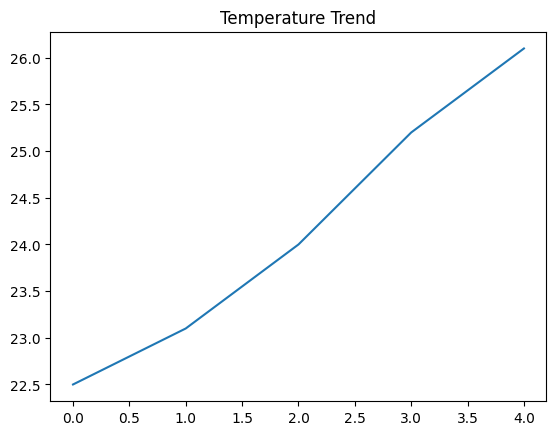

In [10]:
import matplotlib.pyplot as plt

plt.plot(df["temperature"])
plt.title("Temperature Trend")
plt.show()

How to explore unknown .mat files

In [16]:
for key in data.keys():
    if not key.startswith("__"):
        print(key)
        print(type(data[key]))
        print(data[key].shape)
        print()

temperature
<class 'numpy.ndarray'>
(1, 5)

humidity
<class 'numpy.ndarray'>
(1, 5)

sensor_matrix
<class 'numpy.ndarray'>
(3, 3)

